# Cost Breakdown of Provenance Query Execution Time

This jupyter notebook includes a detailed analysis of the provenance query execution time. The provenance query execution consits of 3 phases.
1. GQL-to-Core-GQL translation
2. Query Rewriting
3. Provenance Decoding: consists of interleaved rewritten query execution and provenance decoding itself, that happens in a streamed manner
   
From each benchmark, we use the highest visualizable (the cost breakdown is distinguishable) scale factor FinBench (sf 3) and SNB-BI (sf 3) for the analysis. The analysis follows the following order:
1. Cost breakdown of provenance computation (percentage)
2. Cost breakdown of provenance computation (absolute values)
3. Comparison between rewritten, original query executions and phase 3.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "DejaVu Serif"

pd.set_option('display.float_format', '{:.0f}'.format)

plt.style.use("default")
plt.rcParams.update({
    "font.size": 14,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})

In [2]:
# --------------------------------------------------
# FinBench: Query Name Mappings and Query Groups
# --------------------------------------------------

finbench_query_name = {
    1.3: 'RJ-1', 2.3: 'RJ-2', 3: 'J-1', 4.3: 'RJ-3', 5: 'S-1',
    6: 'S-2', 7.3: 'RJ-4', 8: 'J-2', 9.3: 'R-1', 10: 'MM-1',
    11: 'S-3', 12: 'S-4', 13: 'MM-2', 14: 'MM-3', 15: 'S-5',
    16: 'S-6', 17: 'S-7', 18: 'F-1*', 19: 'SQ-1*', 20: 'SQU-1*'
}

finbench_query_groups = {
    "Simple":       ['S-1', 'S-2', 'S-3', 'S-4', 'S-5', 'S-6', 'S-7', 'J-1', 'J-2'],
    "Intermediate": ['MM-1', 'MM-2', 'MM-3', 'F-1*'],
    "Complex":      ['R-1', 'RJ-1', 'RJ-2', 'RJ-3', 'RJ-4', 'SQ-1*', 'SQU-1*']
}

finbench_query_to_group = {}
for group, queries in finbench_query_groups.items():
    for q in queries:
        finbench_query_to_group[q] = group

finbench_query_order = (
        finbench_query_groups["Simple"] +
        finbench_query_groups["Intermediate"] +
        finbench_query_groups["Complex"]
)

# --------------------------------------------------
# SNB-BI: Query Name Mappings and Query Groups
# --------------------------------------------------

snb_query_name = {
    1: 'MM-1', 2: 'MM-2', 3: 'R-1', 4: 'SQU-1', 5: 'MM-3',
    6: 'MM-4', 7: 'J-1', 8: 'MM-5', 9: 'R-2', 10: 'MMJ-1',
    11: 'MMJ-2', 12: 'R-3', 13: 'MM-6', 14: 'MMJ-3', 15: 'SQU-2',
    16: 'MMJ-4', 17: 'S-1', 18: 'J-2', 19: 'J-3', 20: 'F-1*'
}

snb_query_groups = {
    "Simple": ['S-1', 'J-1', 'J-2', 'J-3'],
    "Intermediate": ['MM-1', 'MM-2', 'MM-3',
                     'MM-4', 'MM-5', 'MM-6', 'F-1*'],
    "Complex": ['MMJ-1', 'MMJ-2', 'MMJ-3', 'MMJ-4',
                'R-1', 'R-2', 'R-3', 'SQU-1', 'SQU-2']
}

snb_query_to_group = {}
for group, queries in snb_query_groups.items():
    for q in queries:
        snb_query_to_group[q] = group

snb_query_order = (
        snb_query_groups["Simple"] +
        snb_query_groups["Intermediate"] +
        snb_query_groups["Complex"]
)

In [3]:
# --------------------------------------------------
# Query Size Computation
# --------------------------------------------------
# label_size    : Total number of labels referenced in a query
# property_size : Total number of properties referenced in a query
# query_size    : label_size + property_size
# --------------------------------------------------

# --------------------------------------------------
# FinBench
# --------------------------------------------------

finbench_query_label_size ={
    1.3 :  5,  2.3 : 7,  3.0 : 6,  4.3: 5,  5.0 :5,
    6.0 : 7,  7.3: 6,  8.: 8 ,  9.3: 4, 10.: 5 ,
    11.: 7 ,12.: 1 , 13.: 5 , 14.: 5 , 15. : 3,
    16. : 3, 17.: 5 , 18.: 5 , 19.:5 , 20.: 5

}

finbench_query_property_size ={
    1.3 :  6,  2.3 : 5,  3. : 8,  4.3: 1,  5. :7,
    6. : 5,  7.3: 4,  8.: 8 ,  9.3: 3, 10.: 3 ,
    11.: 4 ,12.: 4 , 13.: 5 , 14.: 4 , 15. : 4,
    16. : 4, 17.: 5 , 18.: 5 , 19.:9 , 20.: 5

}

finbench_query_size = {}

for key in finbench_query_label_size.keys():
    finbench_query_size[key] = finbench_query_label_size[key]+ finbench_query_property_size[key]
    


# --------------------------------------------------
# SNB-BI
# --------------------------------------------------

snb_query_label_size ={
    1 :  1,  2 : 7,  3 : 17,  4: 18,  5 :8,
    6 : 11,  7: 7,  8: 8 ,  9: 5, 10: 14 ,
    11.: 16 ,12.: 5 , 13.: 11 , 14.: 23 , 15. : 20,
    16. : 25, 17.: 8 , 18.: 6 , 19.:4 , 20.: 13

}

snb_query_property_size ={
    1 :  4,  2 : 6,  3. : 6,  4: 7,  5. :2,
    6. : 2,  7: 2,  8.: 3 ,  9: 5, 10.: 5 ,
    11.: 7 ,12.: 3 , 13.: 4 , 14.: 5 , 15. : 7,
    16. : 4, 17.: 3 , 18.: 4 , 19.:3 , 20.: 7

}

snb_query_size = {}

for key in snb_query_label_size.keys():
    snb_query_size[key] = snb_query_label_size[key]+ snb_query_property_size[key]



In [4]:
finbench_files = [
    "result/phase_metrics/processed/0521_finbench_0.1.log",
    "result/phase_metrics/processed/0530_finbench_0.3.log",
    "result/phase_metrics/processed/0530_finbench_1.log",
    "result/phase_metrics/processed/0530_finbench_3.log",
    "result/phase_metrics/processed/0524_finbench_10.log"
]

test_finbench = pd.concat(
    (
        pd.read_csv(
            f,
            sep="|",
            dtype={"scale_factor": "float64"},
        )
        for f in finbench_files
    ),
    ignore_index=True
)

In [5]:
snb_files = [
    "result/phase_metrics/processed/0531_snb_1.log",
    "result/phase_metrics/processed/0530_snb_3_no_witness.log",
    "result/phase_metrics/processed/0530_snb_10.log"
]

test_snb = pd.concat(
    (
        pd.read_csv(
            f,
            sep="|",
            dtype={"scale_factor": "float64"},
        )
        for f in snb_files
    ),
    ignore_index=True
)

In [10]:
def preprocess_data(raw_data, query_name_mapping):

    ## compute the average execution time for each query
    
    group_cols = ['dataset', 'scale_factor', 'query_number', 'parameter', 'query_type']
    
    # Filter the logs corresponding to the execution times (_result type queries include time taken to write each witness to the log)
    end_df = raw_data[(raw_data["query_type"]!="prov_coarse_result") & (raw_data["query_type"]!="prov_result")].copy()
    end_df = end_df.sort_values(group_cols + ["timestamp"])
    
    end_df["cycle"] = end_df.groupby(group_cols)["prov_phase"].transform(
        lambda s: s.eq("start").cumsum()
    )
    
    # Compute overhead
    phase_times = (
        end_df.pivot_table(
            index=group_cols +["cycle"],
            columns='prov_phase',
            values='timestamp',
            aggfunc='first'
        ).reset_index()
    )
    
    phase_times['total_execution_time'] = phase_times['end'] - phase_times['start']
    phase_times['translation_time'] = phase_times['translated'] - phase_times['start']
    phase_times['rewriting_time'] = phase_times['rewritten'] - phase_times['translated']
    phase_times['rewrite_decode_time'] = phase_times['end'] - phase_times['rewritten']

    prov = phase_times[phase_times["query_type"] == "prov"].copy()
    rewritten = phase_times[phase_times["query_type"] == "rewritten"].copy()
    orig = phase_times[phase_times["query_type"] == "orig"].copy()
    
    merged = prov.merge(
        rewritten,
        on=["dataset", "scale_factor", "query_number", "parameter"],
        how="left",
        suffixes=("","_rewritten")
    )
    
    merged = merged.merge(
        orig,
        on=["dataset", "scale_factor", "query_number", "parameter"],
        how="left",
        suffixes=("","_orig")
    )
    
    merged["query_name"] = merged["query_number"].map(query_name_mapping)
    
    merged = merged.groupby(["dataset", "scale_factor", "query_name"]).agg({
        "total_execution_time": "mean",
        "translation_time": "mean",
        "rewriting_time":"mean",
        "rewrite_decode_time":"mean",
        "total_execution_time_rewritten": "mean",
        "total_execution_time_orig": "mean"
    }
    ).reset_index()

    return merged


In [11]:
merged_finbench = preprocess_data(test_finbench, finbench_query_name)
merged_snb = preprocess_data(test_snb, snb_query_name)

In [90]:
def prepare_data(df, query_order, scale_factor):

    prov_cols = [
        "translation_time",
        "rewriting_time",
        "rewrite_decode_time",
        "total_execution_time",
        "total_execution_time_orig",
        "total_execution_time_rewritten"
    ]

    agg = (
        df[df["scale_factor"] == scale_factor]
        .groupby(["dataset", "query_name"], as_index=False)[prov_cols]
        .mean()
    )

    agg["query_name"] = pd.Categorical(
        agg["query_name"],
        categories=query_order,
        ordered=True
    )

    agg = agg.sort_values("query_name").reset_index(drop=True)

    agg["total"] = agg[prov_cols].sum(axis=1)

    for col in prov_cols:
        agg[col+"_perc"] = (agg[col] / agg["total_execution_time"]) * 100

    return agg

scale_factor = 3
fin = prepare_data(merged_finbench, finbench_query_order, scale_factor)
snb = prepare_data(merged_snb, snb_query_order, scale_factor)

In [91]:
def plot_query_sizes():

    gap = 1.0

    # --------------------------------------------------
    # Build reverse mappings:
    # query_name -> query_id
    # --------------------------------------------------

    fin_name_to_id = {
        v: k for k, v in finbench_query_name.items()
    }

    snb_name_to_id = {
        v: k for k, v in snb_query_name.items()
    }

    # --------------------------------------------------
    # Ordered queries
    # --------------------------------------------------

    fin_queries = finbench_query_order
    snb_queries = snb_query_order

    fin_x = np.arange(len(fin_queries))
    snb_x = np.arange(len(snb_queries)) + len(fin_queries) + gap

    all_x = np.concatenate([fin_x, snb_x])
    all_labels = fin_queries + snb_queries

    # --------------------------------------------------
    # Data
    # --------------------------------------------------

    fin_label_sizes = np.array([
        finbench_query_label_size[fin_name_to_id[q]]
        for q in fin_queries
    ])

    fin_property_sizes = np.array([
        finbench_query_property_size[fin_name_to_id[q]]
        for q in fin_queries
    ])

    snb_label_sizes = np.array([
        snb_query_label_size[snb_name_to_id[q]]
        for q in snb_queries
    ])

    snb_property_sizes = np.array([
        snb_query_property_size[snb_name_to_id[q]]
        for q in snb_queries
    ])

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    fig, ax = plt.subplots(figsize=(18, 6))

    ax.bar(
        fin_x,
        fin_property_sizes,
        color="#F58518",
        label="Properties"
    )

    ax.bar(
        fin_x,
        fin_label_sizes,
        bottom=fin_property_sizes,
        color="#4C78A8",
        label="Labels"
    )

    ax.bar(
        snb_x,
        snb_property_sizes,
        color="#F58518"
    )

    ax.bar(
        snb_x,
        snb_label_sizes,
        bottom=snb_property_sizes,
        color="#4C78A8"
    )

    # --------------------------------------------------
    # X axis
    # --------------------------------------------------

    ax.set_xticks(all_x)
    ax.set_xticklabels(all_labels,
                       rotation=45,
                       ha="right")

    # Dataset separator

    ax.axvline(
        len(fin_queries) + gap/2 - 0.5,
        color="black",
        linestyle="--",
        linewidth=2
    )

    # --------------------------------------------------
    # Group separators
    # --------------------------------------------------

    def add_groups(x0, groups):

        s = len(groups["Simple"])
        i = len(groups["Intermediate"])

        ax.axvline(
            x0 + s - 0.5,
            color="gray",
            linestyle="--",
            alpha=0.7
        )

        ax.axvline(
            x0 + s + i - 0.5,
            color="gray",
            linestyle="--",
            alpha=0.7
        )

    add_groups(0, finbench_query_groups)
    add_groups(len(fin_queries) + gap, snb_query_groups)

    # --------------------------------------------------
    # Dataset labels
    # --------------------------------------------------

    ax.text(
        fin_x.mean(),
        -0.25,
        "FinBench",
        transform=ax.get_xaxis_transform(),
        ha="center",
        fontsize=16
    )

    ax.text(
        snb_x.mean(),
        -0.25,
        "SNB",
        transform=ax.get_xaxis_transform(),
        ha="center",
        fontsize=16
    )

    # --------------------------------------------------
    # Group labels
    # --------------------------------------------------

    def add_group_titles(x0, groups):

        s = len(groups["Simple"])
        i = len(groups["Intermediate"])
        c = len(groups["Complex"])

        ax.text(
            x0 + (s-1)/2,
            0.95,
            "Simple",
            transform=ax.get_xaxis_transform(),
            ha="center",
            fontsize=14
        )

        ax.text(
            x0 + s + (i-1)/2,
            0.95,
            "Intermediate",
            transform=ax.get_xaxis_transform(),
            ha="center",
            fontsize=14
        )

        ax.text(
            x0 + s + i + (c-1)/2,
            0.95,
            "Complex",
            transform=ax.get_xaxis_transform(),
            ha="center",
            fontsize=14
        )

    add_group_titles(0, finbench_query_groups)
    add_group_titles(len(fin_queries)+gap, snb_query_groups)

    # --------------------------------------------------
    # Formatting
    # --------------------------------------------------

    ax.set_ylabel("Query Size")
    ax.set_xlabel("Queries")

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15),
        ncol=2,
        frameon=False
    )

    plt.tight_layout()
    plt.show()

In [92]:
def plot_cost_breakdown(fin_df, snb_df, prov_cols, plot_type=1):  # plot_type: 1=Percentage, 2= Absolute

    gap = 1.0

    fin_x = np.arange(len(fin))
    snb_x = np.arange(len(snb)) + len(fin) + gap

    all_x = np.concatenate([fin_x, snb_x])
    all_labels = fin["query_name"].astype(str).tolist() + snb["query_name"].astype(str).tolist()

    fig, ax = plt.subplots(figsize=(18, 6))

    colors = ["#4C78A8", "#F58518", "#54A24B"]

    labels = [
        "Core-GQL Translation",
        "Query Rewriting",
        "Provenance Decoding"
    ]

    def draw(x, df, label=None):

        bottom = np.zeros(len(df))

        for col, color, name in zip(prov_cols, colors, labels):

            ax.bar(
                x,
                df[col],
                bottom=bottom,
                color=color,
                label=name if label == "FinBench" else None
            )

            bottom += df[col]

    draw(fin_x, fin, "FinBench")
    draw(snb_x, snb, "SNB")

    ax.set_xticks(all_x)
    ax.set_xticklabels(all_labels, rotation=45, ha="right")

    # Dataset separator
    ax.axvline(len(fin) + gap/2 - 0.5,
               color="black",
               linestyle="--",
               linewidth=2)

    # Group separators
    def add_groups(x0, groups, plot_type):

        s = len(groups["Simple"])
        i = len(groups["Intermediate"])

        ax.axvline(x0 + s - 0.5, color="gray", linestyle="--", alpha=0.7)
        ax.axvline(x0 + s + i - 0.5, color="gray", linestyle="--", alpha=0.7)

        if plot_type == 2: #For absolute
     
            ax.text(
                x0 + (s - 1) / 2,
                0.92,
                "Simple",
                transform=ax.get_xaxis_transform(),
                ha="center",
                fontsize=18,
                # fontweight="bold"
            )
    
            ax.text(
                x0 + s + (i - 1) / 2,
                0.92,
                "Inter.",
                transform=ax.get_xaxis_transform(),
                ha="center",
                fontsize=18,
                # fontweight="bold"
            )
    
            ax.text(
                x0 + s + i + (len(groups["Complex"]) - 1) / 2,
                0.92,
                "Complex",
                transform=ax.get_xaxis_transform(),
                ha="center",
                fontsize=18,
                # fontweight="bold"
            )

    add_groups(0, finbench_query_groups, plot_type)
    add_groups(len(fin) + gap, snb_query_groups, plot_type)

    if plot_type == 1:
        ax.set_ylim(0, 100)
        ax.set_ylabel("Percentage of Total Cost (%)", fontsize=18)

    elif plot_type == 2:
        ax.set_yscale("log")
        ax.set_ylabel("Execution Time [log] (ms)", 
                  # fontweight="bold",
        fontsize=18,
                 )

    ax.set_xlabel("Dataset & Queries", fontsize=18, labelpad=15)

    ax.text(
        fin_x.mean(),
        -0.26,
        "FinBench (sf 3)",
        transform=ax.get_xaxis_transform(),
        ha="center",
        fontsize=18
    )

    ax.text(
        snb_x.mean(),
        -0.26,
        "SNB (sf 3)",
        transform=ax.get_xaxis_transform(),
        ha="center",
        fontsize=18
    )
    
    ax.legend(loc="upper center",
              bbox_to_anchor=(0.5, 1.2),
              ncol=3,
              frameon=False,
             fontsize=18)

    plt.margins(x=0.01)
    plt.tight_layout()
    # plt.savefig("result/plots/cost_breakdown_perc.png", dpi=300, bbox_inches="tight")
    plt.show()

## Cost Breakdown (as Percentage)

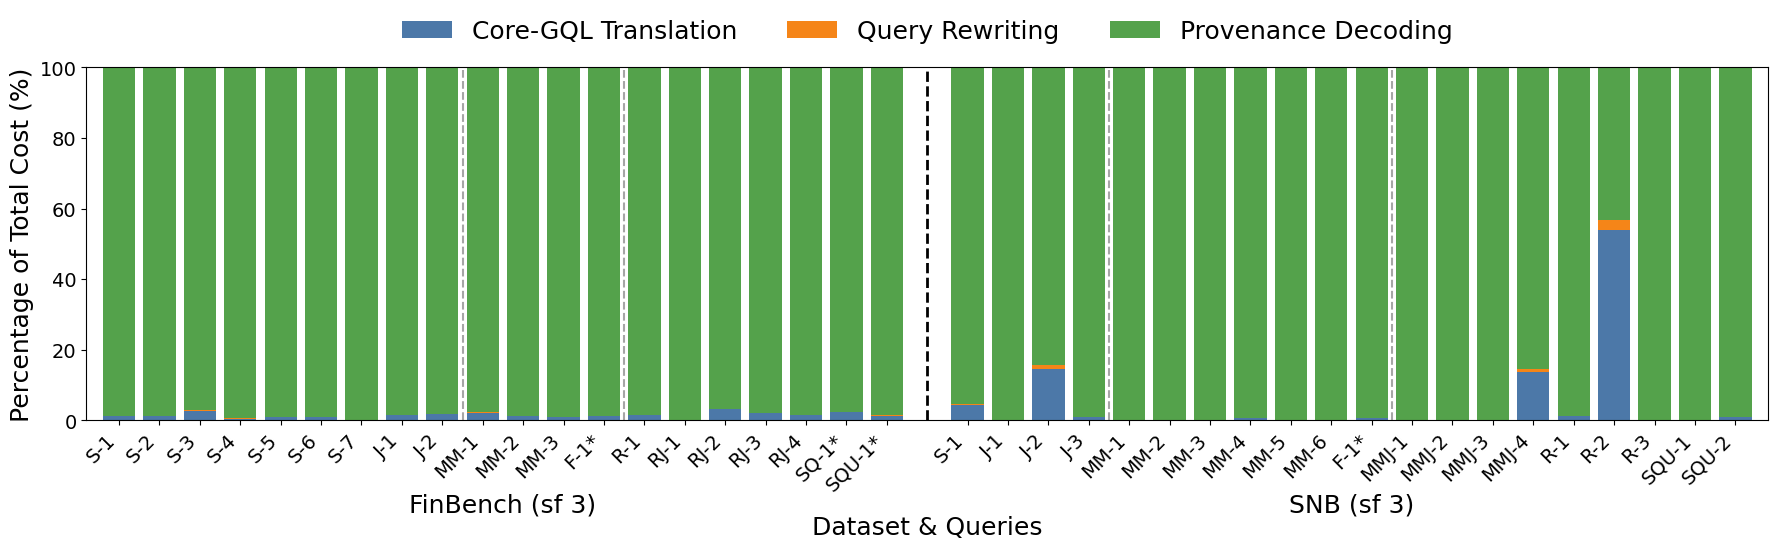

In [93]:
prov_cols = [
    "translation_time_perc",
    "rewriting_time_perc",
    "rewrite_decode_time_perc"
]
plot_cost_breakdown(fin,snb, prov_cols)

**Observations:**
* In general across all queries, 99% of the execution time is consumed by provenance encoding (phase 3).
* Query ```R-2``` stands out with provenance encoding occupying less than 60% of the total execution time. (Need to explore whether the Core-GQL translation takes more time or the provenance decoding takes less time)
* In query ```J-2``` and ```MMJ-4```, the Core-GQL translation contributes close to 20% of the total execution time. Need to be explored.

### Cost Breakdown (Absolute)

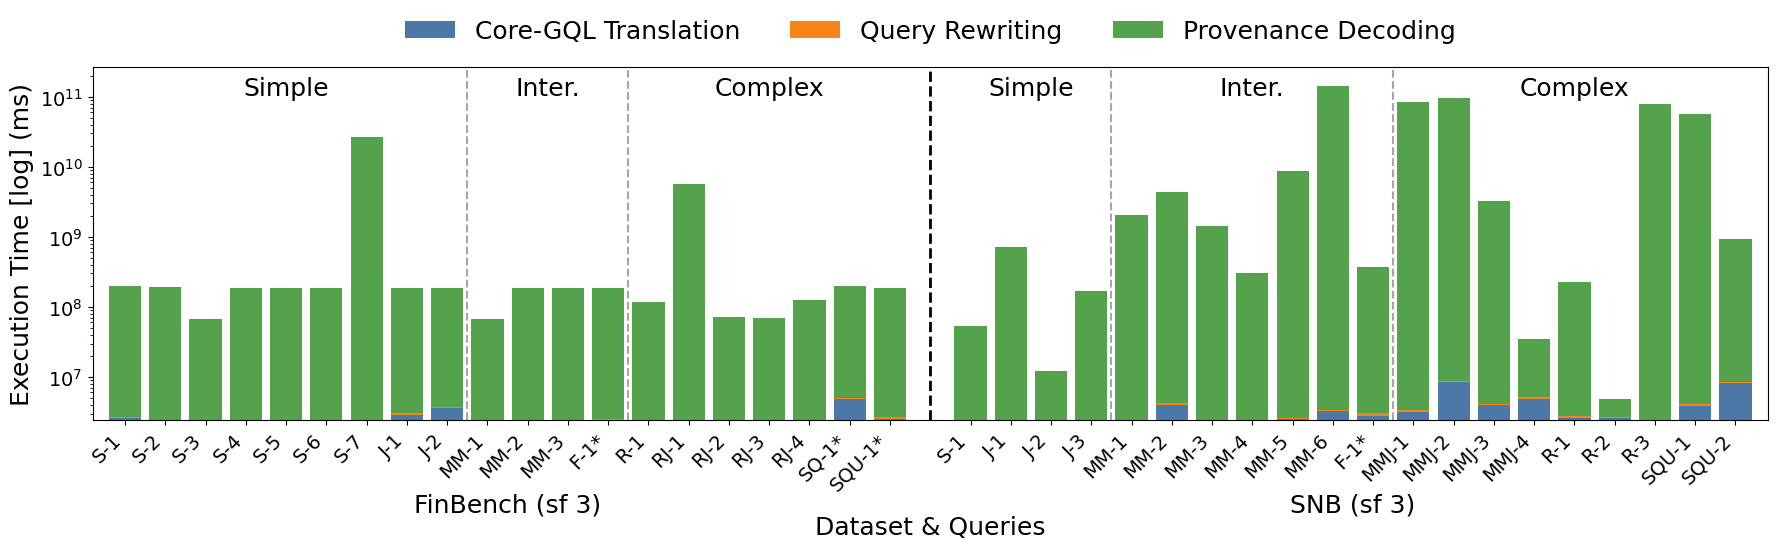

In [94]:
prov_cols = [
    "translation_time",
    "rewriting_time",
    "rewrite_decode_time"
]
plot_cost_breakdown(fin,snb, prov_cols,2)

**Observations:**
* The reduction in the contribution of the provenance decoding phase in queries ```J-2``` and ```R-2``` can be explained by their low provenance decoding times.
* Queries```J-1, J-2,``` and ```SQ-1*``` in FinBench and ```MM-2, MM-6, MMJ-1, MMJ-2, MMJ-3, MMJ-4, SQU-1,``` and ```SQU-2``` in SNB-BI has higher execution times at Core-GQL translation phase (Could it be the query complexities based on the number of labels and properties referenced in the queries?)

### Explore the query sizes 

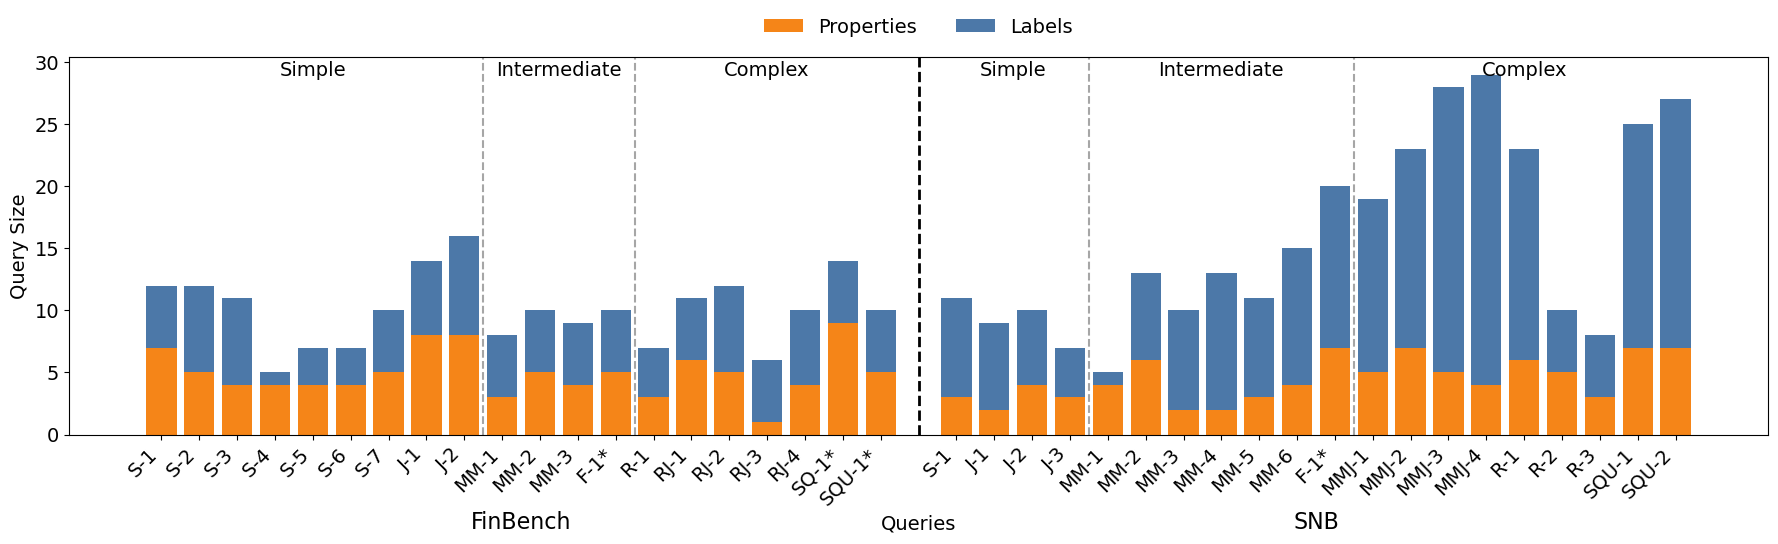

In [95]:
plot_query_sizes()

**Observations:**
* Queries```J-1, J-2,``` and ```SQ-1*``` in FinBench and ```MM-2, MM-6, MMJ-1, MMJ-2, MMJ-3, MMJ-4, SQU-1,``` and ```SQU-2``` in SNB-BI have the highest number of query sizes.
* While query ```S-1``` and ```S-2``` in FinBench have the same query size, properties contribute more to the query size of ```S-1``` compared to ```S-2```. ```S-1``` seem to have slightly a higher execution time for Core-GQL translation than in ```S-2```. This scenario is also visible in the query pairs (```MM-2, MM-4```), (```MMJ-2, R-1```) in SNB-BI. However, not enough data to confirm a pattern

## Comparison of Rewritten, Original queries and Complete Provenance Decoding
Recall that provenance encoding (phase 3) includes execution of the rewritten query and the provenance decoding itself. These two computations occur within our implementation in a streamed manner. Therefore it is not possible to measure the execution time of each phase separately and correctly. Nevertheless, to estimate the overhead introduced by provenance decoding, we compare the execution time of the rewritten query with that of the complete provenance decoding phase.


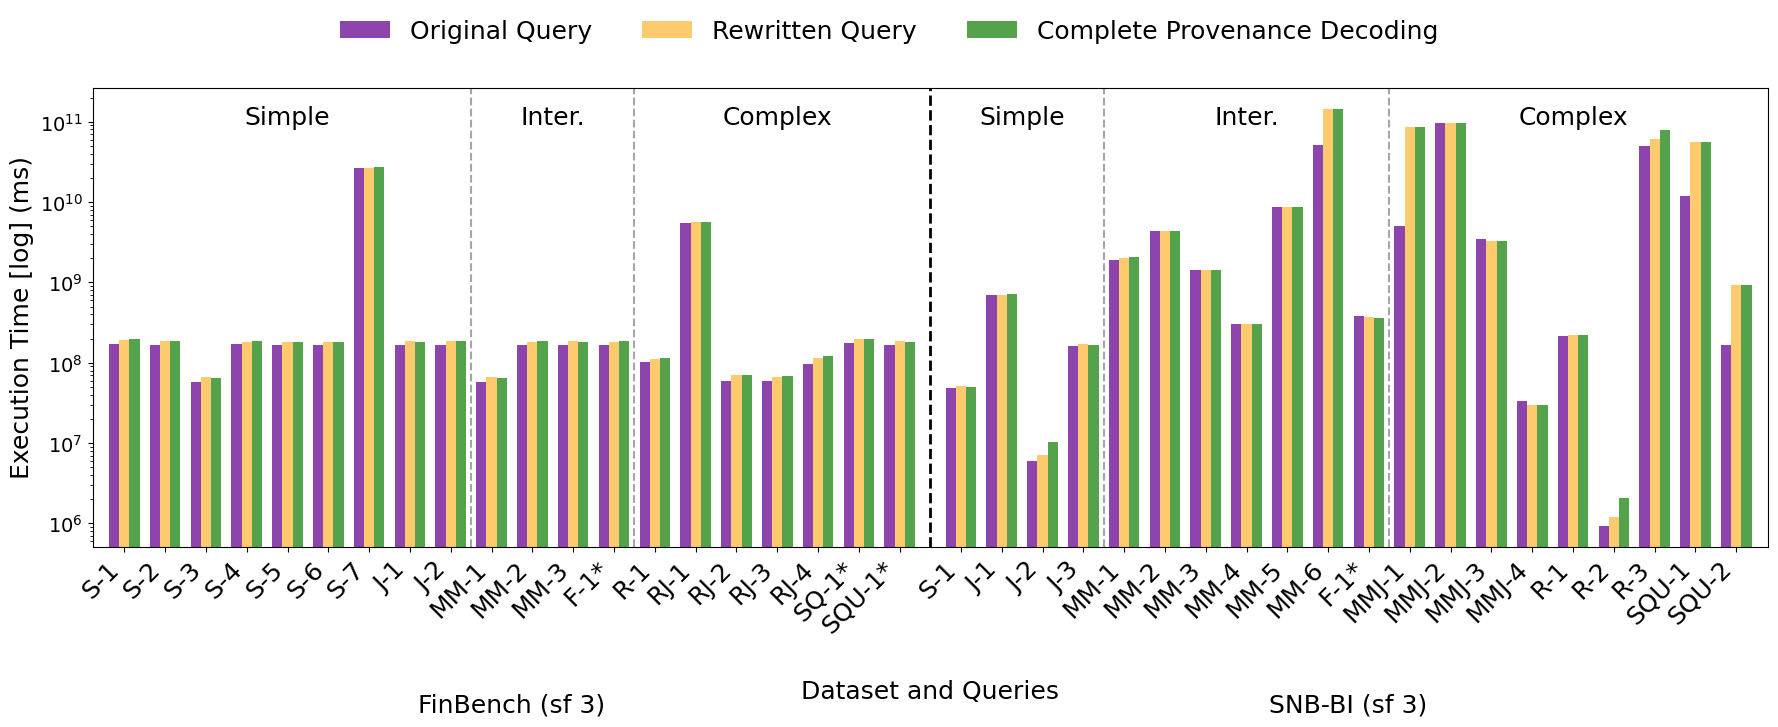

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prov_cols = [
    "total_execution_time_orig",
    "total_execution_time_rewritten",
    "rewrite_decode_time"
]

def plot_prov_decode_cost_breakdown(
    fin,
    snb,
    font_size
):

    gap = 0.5

    fin_x = np.arange(len(fin))
    snb_x = np.arange(len(snb)) + len(fin) + gap

    all_x = np.concatenate([fin_x, snb_x])

    all_labels = (
        fin["query_name"].astype(str).tolist()
        + snb["query_name"].astype(str).tolist()
    )

    fig, ax = plt.subplots(figsize=(18, 7))

    metrics = prov_cols

    colors = [
        "#8E44AD",
        "#FDCB6E",
        "#54A24B",  # green (rewrite_decode_time)
    ]

    labels = [
        "Original Query",
        "Rewritten Query",
        "Complete Provenance Decoding",
    ]

    # bar offsets for grouped bars
    bar_width = 0.25
    offsets = np.linspace(-bar_width, bar_width, len(metrics))

    def draw(x, df, dataset):

        bottom = np.zeros(len(df))

        for col, color, name, off in zip(metrics, colors, labels, offsets):

            ax.bar(
                x + off,
                df[col],
                width=bar_width,
                color=color,
                label=name if dataset == "FinBench" else None
            )

    draw(fin_x, fin, "FinBench")
    draw(snb_x, snb, "SNB")

    # Dataset separator
    sep = len(fin) + gap / 2 - 0.5
    ax.axvline(sep, color="black", linestyle="--", linewidth=2)

    ax.set_xticks(all_x)
    ax.set_xticklabels(all_labels, rotation=45, ha="right", fontsize=18)

    # Group separators
    def add_group_lines(x_start, groups):
        s = len(groups["Simple"])
        i = len(groups["Intermediate"])

        ax.axvline(x_start + s - 0.5, color="gray", linestyle="--", alpha=0.7)
        ax.axvline(x_start + s + i - 0.5, color="gray", linestyle="--", alpha=0.7)

        ax.text(
            x_start + (s - 1) / 2,
            0.92,
            "Simple",
            transform=ax.get_xaxis_transform(),
            ha="center",
            fontsize=font_size,
        )

        ax.text(
            x_start + s + (i - 1) / 2,
            0.92,
            "Inter.",
            transform=ax.get_xaxis_transform(),
            ha="center",
            fontsize=font_size,
        )

        ax.text(
            x_start + s + i + (len(groups["Complex"]) - 1) / 2,
            0.92,
            "Complex",
            transform=ax.get_xaxis_transform(),
            ha="center",
            fontsize=font_size,
        )

    add_group_lines(0, finbench_query_groups)
    add_group_lines(len(fin) + gap, snb_query_groups)

    ax.set_ylabel("Execution Time [log] (ms)", fontsize=font_size)
    ax.set_xlabel("Dataset and Queries", labelpad=30, fontsize=font_size)
    ax.set_yscale("log")

    ax.text(
        fin_x.mean(),
        -0.36,
        "FinBench (sf 3)",
        transform=ax.get_xaxis_transform(),
        ha="center",
        fontsize=font_size,
    )

    ax.text(
        snb_x.mean(),
        -0.36,
        "SNB-BI (sf 3)",
        transform=ax.get_xaxis_transform(),
        ha="center",
        fontsize=font_size,
    )

    fig.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.10),
        ncol=3,
        frameon=False,
        fontsize=font_size,
    )

    plt.margins(x=0.01)
    plt.tight_layout()
    # plt.savefig("result/plots/cost_breakdown_grouped.png",
    #             dpi=300,
    #             bbox_inches="tight")
    plt.show()



plot_prov_decode_cost_breakdown(
    fin,
    snb,
    font_size=18
)

**Observations:**
* Overall, the execution of the rewritten query dominates the total provenance decoding time.
* Nevertheless, comparing the execution times of the original and rewritten queries shows that the overhead introduced by query rewriting for provenance computation is generally low.